# **Simple Linear Regression from Scratch**



## 0.ライブラリのインポートとデータの生成

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

data = []
a = 2.5
b = 0.5
for i in range(20):
    x = random.uniform(0, 35)
    noise = random.uniform(-2.5, 2.5)
    y = a + b*x + noise
    data.append([x,y])

input_data = np.array(data)
data_number = input_data.shape[0]

## 1.アルゴリズム

### 1.1.誤差関数

初期重み：w0,w1　予測値：y'　実測値：y　残差：y' - y = w0 + w1x1 - y1

**残差平方和**

(y' - y)^2

=(w0 + w1x1 - y1)^2

=w0^2 + w1^2x1^2 + y1^2 + 2w0w1x1 - 2w1x1y1 - 2y1w0

**偏微分**

dw0 = 2w0 + 2w1x1 - 2y1

dw1 = x1(2w1x1 + 2w0 - 2y1)


### 1.2.勾配降下法

学習率(step size) を alpha とすると

w0 = w0 - alpha*(dw0)

w1 = w1 - alpha*(dw1)

In [ ]:
epochs = 50
alpha = 0.00002

w0 = random.uniform(0.01, 0.2)
w1 = random.uniform(0.01, 0.2)

loss_history = []

for j in range(epochs):
  dw0 = 0
  dw1 = 0
  loss = 0

  for i in range(data_number):
    x = input_data[i,0]
    y = input_data[i,1]
    y_pred = w0 + w1*x
    loss += (y_pred - y)**2

    dw0 = dw0 + 2*w0 + 2*w1*x - 2*y
    dw1 = dw1 + x*(2*w1*x + 2*w0 - 2*y)

  loss_history.append(loss)

  w0 = w0 - alpha*dw0
  w1 = w1 - alpha*dw1

## 2.モデルの可視化

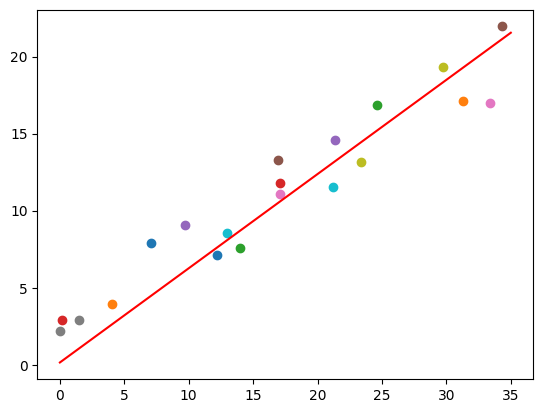

In [ ]:
x = np.linspace(0,35,100)
model_y = w0 + w1*x
plt.plot(x, model_y, label="model", color="red")
for u in range(data_number):
  plt.scatter(input_data[u,0],input_data[u,1])
plt.show()

## 3.検証

### 3.1.学習の進捗

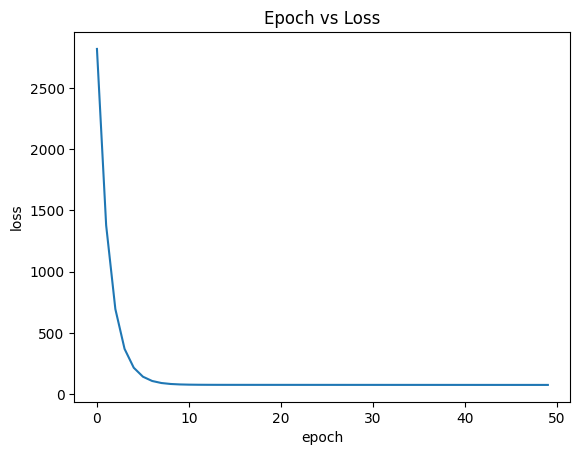

In [ ]:
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Epoch vs Loss")
plt.show()

### 3.2.直線の比較

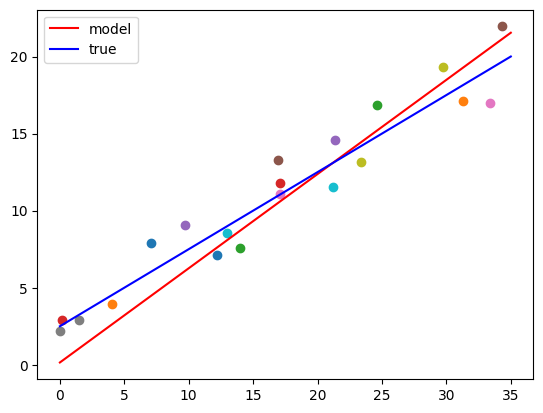

In [ ]:
x = np.linspace(0,35,100)
true_y = a + b*x
plt.plot(x, model_y, label="model", color="red")
plt.plot(x, true_y, label="true", color="blue")
for u in range(data_number):
  plt.scatter(input_data[u,0],input_data[u,1])
plt.legend()
plt.show()

### 3.3.パラメータの比較

真のデータ

w0 = 2.5

w1 = 0.5

学習の結果

w0 = 0.15

w1 = 0.61

In [ ]:
print(a, b, w0, w1)

2.5 0.5 0.14913379926662765 0.6112638542625874
